# Linear Regression from Scratch (Pandas Only)
Two approaches: OLS closed-form and Batch Gradient Descent — no numpy, no sklearn.

## 1. Load Dataset
- `as_frame=False` (default) → `raw` is a Bunch (dict-like) where `raw.data` is a **numpy array**, `raw.frame` is **None**
- `as_frame=True` → `raw` is a Bunch (dict-like) where `raw.data` is a **pandas DataFrame**, `raw.frame` = **data + target** combined as one full DataFrame
    - `raw` when not default gives these keys as dict *['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR']*

In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
 
raw = fetch_california_housing(as_frame=True)
df = raw.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Train/Test Split (80/20, no shuffle)
- If you use `df[features]` directly and later do something like `X_train["new_col"] = 1` or scale a column, pandas throws a **SettingWithCopyWarning** and sometimes silently modifies `df` itself — your original dataset gets corrupted without you realizing it.
    - **Analogy:** Imagine `df` is a **library's original book**. `df[features]` is just you **pointing at that book on the shelf** — if you scribble notes in it, you've ruined the library's copy. `.copy()` is **photocopying that book** — scribble all you want, original is safe.
    - **X_all** is like a **kitchen knife you borrowed** — you're going to sharpen it, reshape it, use it hard — so you make a **duplicate** first so the owner's knife stays intact.
    - **y_all** is like a **recipe card you borrowed** — you're only **reading** it, never writing on it — so no need to photocopy it, just glance and use.
- `sample(frac=1)` means **"give me 100% of the rows but in a random order"** — that's just shuffling.
- `random_state=42` means **"use the same shuffle every time"** — so your train/test split is reproducible.
- `reset_index(drop=True)` means **"renumber rows 0,1,2... after shuffling"** — because after shuffle, index is jumbled like 4,1,7,2... and you want clean 0,1,2...
    - **Analogy:** You have a **deck of 52 cards** (`frac=1` = all cards). `sample` **shuffles the deck**. `random_state` is like saying **"shuffle it the same way I showed you yesterday"** — same seed = same shuffle every time. `reset_index` is like **re-numbering the cards 1-52 after shuffling** so positions make sense again.

In [2]:
def train_test_split_scratch(X, y, test_size=0.2, random_state=42):
    df_temp = X.copy()
    df_temp["__target__"] = y.values
    
    df_temp = df_temp.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    split_idx = int(len(df_temp) * (1 - test_size))
    train = df_temp.iloc[:split_idx]
    test  = df_temp.iloc[split_idx:]
    
    X_train = train.drop("__target__", axis=1).reset_index(drop=True)
    X_test  = test.drop("__target__", axis=1).reset_index(drop=True)
    y_train = train["__target__"].reset_index(drop=True)
    y_test  = test["__target__"].reset_index(drop=True)
    
    return X_train, X_test, y_train, y_test

In [3]:
features = raw.feature_names
target   = raw.target_names[0]

X_all = df[features].copy()
y_all = df[target]

X_train, X_test, y_train, y_test = train_test_split_scratch(X_all, y_all, test_size=0.2, random_state=42)

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 16,512  |  Test: 4,128


In [4]:
features = raw.feature_names
target = raw.target_names[0]

X_all = df[features].copy()
X_all.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## 3. Add Bias Column

In [5]:
X_train.insert(0, "bias", 1.0)
X_test.insert(0, "bias", 1.0)
X_train.head(3)

,bias,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,1.0,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01
1,1.0,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46
2,1.0,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44


---
# Approach A: OLS Closed-Form
$$\beta = (X^T X)^{-1} X^T y$$

Exact solution in one shot. Requires inverting an (p×p) matrix — expensive when p is large,
impossible when XᵀX is singular.

## 4. Matrix Inverse via Gauss-Jordan (Pure Pandas)

In [6]:
def df_inv(A: pd.DataFrame) -> pd.DataFrame:
    n    = len(A)
    cols = list(A.columns)
    aug  = A.astype(float).copy()
    eye  = pd.DataFrame(
        [[float(i == j) for j in range(n)] for i in range(n)],
        index=A.index, columns=[f"_i{c}" for c in cols]
    )
    aug = pd.concat([aug, eye], axis=1)
    for k, col in enumerate(cols):
        aug.iloc[k] = aug.iloc[k] / aug.iloc[k, k]
        for r in range(n):
            if r != k:
                aug.iloc[r] -= aug.iloc[r, k] * aug.iloc[k]
    inv = aug[[f"_i{c}" for c in cols]].copy()
    inv.columns = cols
    inv.index   = cols
    return inv

## 5. Solve & Evaluate (OLS)

In [7]:
XtX  = X_train.T.dot(X_train)
Xty  = X_train.T.dot(y_train)
beta_ols = df_inv(XtX).dot(Xty)

pd.DataFrame({"Feature": beta_ols.index, "Coefficient": beta_ols.values}).set_index("Feature")

,Coefficient
Feature,
bias,-36.350578
MedInc,0.444781
HouseAge,0.009401
AveRooms,-0.120494
AveBedrms,0.661341
Population,-0.000008
AveOccup,-0.004139
Latitude,-0.414768
Longitude,-0.427852


In [8]:
def metrics(y_true, y_pred, label):
    resid  = y_true.values - y_pred.values
    mse    = pd.Series(resid ** 2).mean()
    rmse   = mse ** 0.5
    ss_res = (pd.Series(resid) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    r2     = 1 - ss_res / ss_tot
    print(f"{label:<6} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

print("--- OLS ---")
metrics(y_train, X_train.dot(beta_ols), "Train")
metrics(y_test,  X_test.dot(beta_ols),  "Test")

--- OLS ---
Train  | MSE: 0.5173 | RMSE: 0.7192 | R²: 0.6105
Test   | MSE: 0.5552 | RMSE: 0.7451 | R²: 0.5875


---
# Approach B: Batch Gradient Descent

Iteratively updates β by moving in the direction that reduces MSE the most.

**Loss (MSE):**
$$J(\beta) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

**Gradient:**
$$\frac{\partial J}{\partial \beta} = \frac{2}{n} X^T (X\beta - y)$$

**Update rule:**
$$\beta \leftarrow \beta - \alpha \cdot \frac{\partial J}{\partial \beta}$$

- $\alpha$ = learning rate (step size)
- Repeat for N epochs until loss converges
- **Requires feature scaling** — gradient magnitudes vary wildly across features otherwise

## 6. Feature Scaling (Min-Max, Pure Pandas)

In [9]:
# Scale only the feature columns (not the bias column)
feat_cols = [c for c in X_train.columns if c != "bias"]

X_min = X_train[feat_cols].min()
X_max = X_train[feat_cols].max()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[feat_cols] = (X_train[feat_cols] - X_min) / (X_max - X_min)
X_test_scaled[feat_cols]  = (X_test[feat_cols]  - X_min) / (X_max - X_min)

X_train_scaled.head(3)

,bias,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,1.0,0.081468,0.470588,0.025409,0.020423,0.048563,0.002267,0.374070,0.531873
1,1.0,0.140095,0.568627,0.031842,0.025499,0.054620,0.001303,0.276302,0.487052
2,1.0,0.205528,1.000000,0.023776,0.025273,0.045692,0.000241,0.558980,0.190239


## 7. Gradient Descent Training Loop

In [10]:
def gradient_descent(X: pd.DataFrame, y: pd.Series,
                     lr: float = 0.1,
                     epochs: int = 1000,
                     log_every: int = 100):
    """
    Batch Gradient Descent for Linear Regression (pure pandas).
    Returns: beta (pd.Series), loss_history (list)
    """
    n      = len(X)
    # initialise all weights to zero
    beta   = pd.Series(0.0, index=X.columns)
    losses = []

    for epoch in range(1, epochs + 1):
        y_hat    = X.dot(beta)                          # predictions:  (n,)
        residual = y_hat - y                            # errors:       (n,)
        loss     = (residual ** 2).mean()               # MSE
        gradient = X.T.dot(residual) * (2 / n)         # gradient:     (p,)
        beta     = beta - lr * gradient                 # update
        losses.append(loss)

        if epoch % log_every == 0 or epoch == 1:
            print(f"Epoch {epoch:>5} | MSE: {loss:.6f}")

    return beta, losses


beta_gd, loss_history = gradient_descent(
    X_train_scaled, y_train, lr=0.1, epochs=1000, log_every=100
)

Epoch     1 | MSE: 5.603461
Epoch   100 | MSE: 0.957185
Epoch   200 | MSE: 0.783064
Epoch   300 | MSE: 0.691582
Epoch   400 | MSE: 0.642390
Epoch   500 | MSE: 0.615020
Epoch   600 | MSE: 0.598995
Epoch   700 | MSE: 0.588936
Epoch   800 | MSE: 0.582078
Epoch   900 | MSE: 0.576994
Epoch  1000 | MSE: 0.572940


## 8. Loss Curve

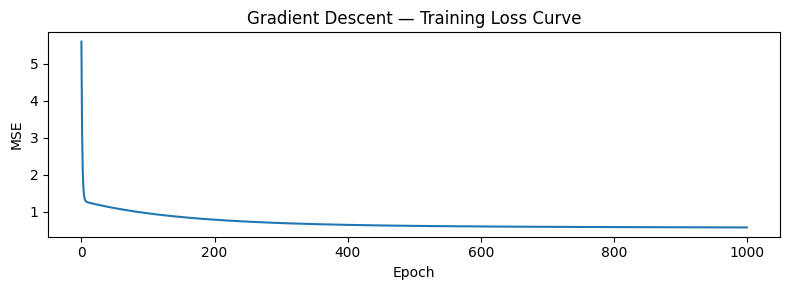

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Gradient Descent — Training Loss Curve")
plt.tight_layout()
plt.show()

## 9. Evaluate (Gradient Descent)

In [12]:
print("--- Gradient Descent ---")
metrics(y_train, X_train_scaled.dot(beta_gd), "Train")
metrics(y_test,  X_test_scaled.dot(beta_gd),  "Test")

--- Gradient Descent ---
Train  | MSE: 0.5729 | RMSE: 0.7569 | R²: 0.5686
Test   | MSE: 0.6035 | RMSE: 0.7769 | R²: 0.5516


## 10. OLS vs Gradient Descent — Side-by-Side

> The two methods solve the same problem differently.
> GD coefficients are not directly comparable to OLS because the features are scaled —
> but the final MSE and R² should be close.

In [13]:
print("=== OLS (unscaled) ===")
metrics(y_train, X_train.dot(beta_ols), "Train")
metrics(y_test,  X_test.dot(beta_ols),  "Test")

print("\n=== Gradient Descent (scaled) ===")
metrics(y_train, X_train_scaled.dot(beta_gd), "Train")
metrics(y_test,  X_test_scaled.dot(beta_gd),  "Test")

=== OLS (unscaled) ===
Train  | MSE: 0.5173 | RMSE: 0.7192 | R²: 0.6105
Test   | MSE: 0.5552 | RMSE: 0.7451 | R²: 0.5875

=== Gradient Descent (scaled) ===
Train  | MSE: 0.5729 | RMSE: 0.7569 | R²: 0.5686
Test   | MSE: 0.6035 | RMSE: 0.7769 | R²: 0.5516


## Save Model to `../Models/`

In [16]:
import json
import os
# Scaling params used by GD (needed for inference at comparison time)
feat_cols = [c for c in X_train.columns if c != 'bias'] if 'bias' in X_train.columns else list(X_train.columns)

# Re-derive min/max from X_train (feature cols before bias insertion)
_feat_names = list(raw.feature_names)
_X_train_raw = X_train[_feat_names] if 'bias' in X_train.columns else X_train
x_min = _X_train_raw.min().to_dict()
x_max = _X_train_raw.max().to_dict()

model_data = {
    'feature_names': list(raw.feature_names),
    'split':         {'test_size': 0.2, 'random_state': 42},
    'ols': {
        'coefficients': beta_ols.to_dict()          # includes 'bias' key
    },
    'gd': {
        'coefficients': beta_gd.to_dict(),           # includes 'bias' key
        'x_min': x_min,
        'x_max': x_max
    }
}

save_path = '../Models/lr_scratch.json'
with open(save_path, 'w') as f:
    json.dump(model_data, f)

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")

Saved → ../Models/lr_scratch.json  (1.2 KB)
